# Detector health data
1. Download the example data from [here](https://drive.google.com/file/d/1zYW2Qwtr6Sny6q2sHn-SD6eALmDf2rhO).
2. Parse it and plot it

For science analysis, which requires gain vs. temperature adjustment, the health data is critical.

In [1]:
import datetime as dtime
import gzip
import pathlib

import matplotlib.pyplot as plt
import umndet.helpers as hp

# Uncomment for high DPI display
%config InlineBackend.figure_format = 'retina'

plt.style.use("style")

In [2]:
tstamps = []
sipm_temps = []
arm_temps = []

file = pathlib.Path("det_2026-270-19-31-06_0.bin.gz")
health = hp.read_det_health(file, open_func=gzip.open)
for h in health:
    tstamps.append(
        dtime.datetime.fromtimestamp(h.timestamp, dtime.UTC)
    )
    sipm_temps.append(h.m5.sipm_temp / 100)
    arm_temps.append(h.m5.arm_temp / 100)

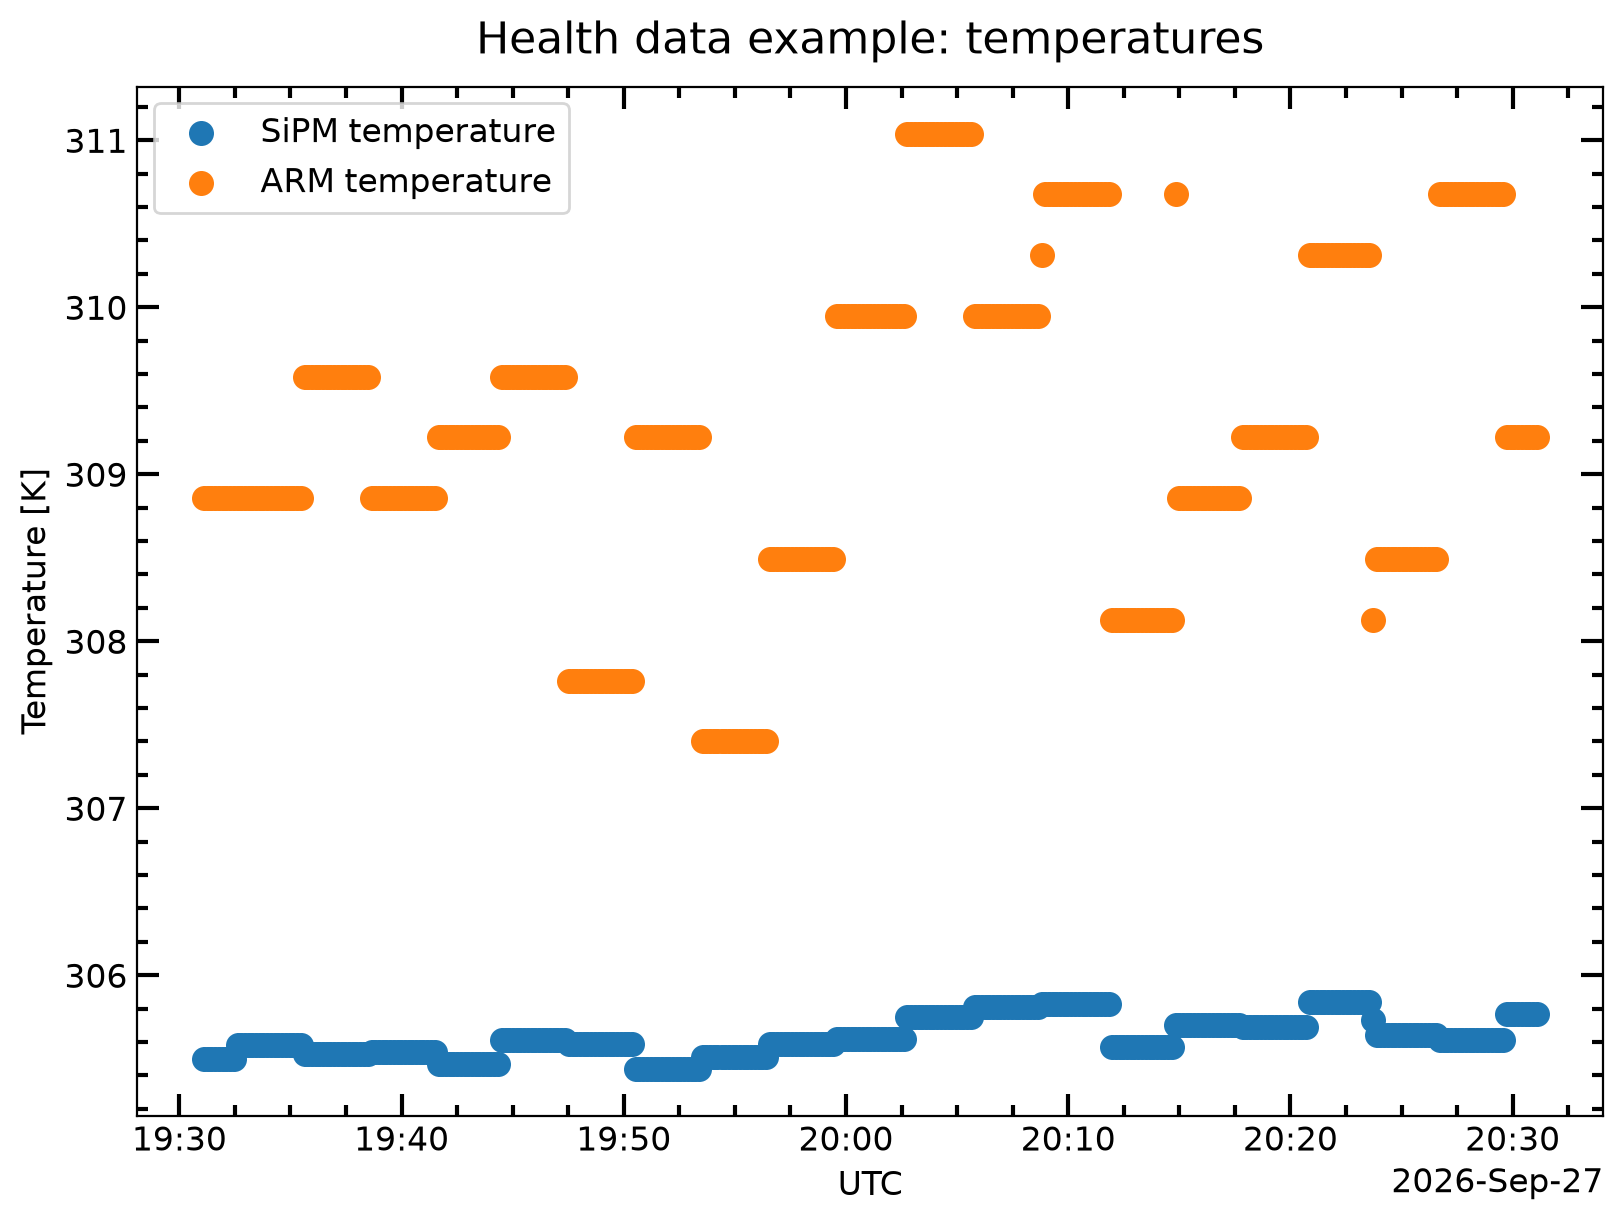

In [3]:
fig, ax = plt.subplots()
ax.scatter(tstamps, sipm_temps, label='SiPM temperature')
ax.scatter(tstamps, arm_temps, label='ARM temperature')

ax.set(
    xlabel="UTC",
    ylabel="Temperature [K]",
    title="Health data example: temperatures"
)
ax.legend()
plt.show()